In [1]:
import yahooquery as yq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_yahoo_adjclose(symbol, start="1993-04-13", end="2026-01-01", interval="1d"):
    hist = yq.Ticker(symbol).history(interval=interval, start=start, end=end).reset_index()
    hist["date"] = pd.to_datetime(hist["date"])
    return hist[["date", "adjclose"]].copy()


vix = load_yahoo_adjclose("^VIX")
sp500 = load_yahoo_adjclose("^GSPC").rename(columns={"adjclose": "sp500_adjclose"})

In [3]:
# calculate vix and sp500 returns
vix["vix_returns"] = vix["adjclose"].pct_change()
sp500["sp500_returns"] = sp500["sp500_adjclose"].pct_change()

In [4]:
np.corrcoef(vix["adjclose"], sp500["sp500_adjclose"])[0, 1]

np.float64(-0.08079105553900033)

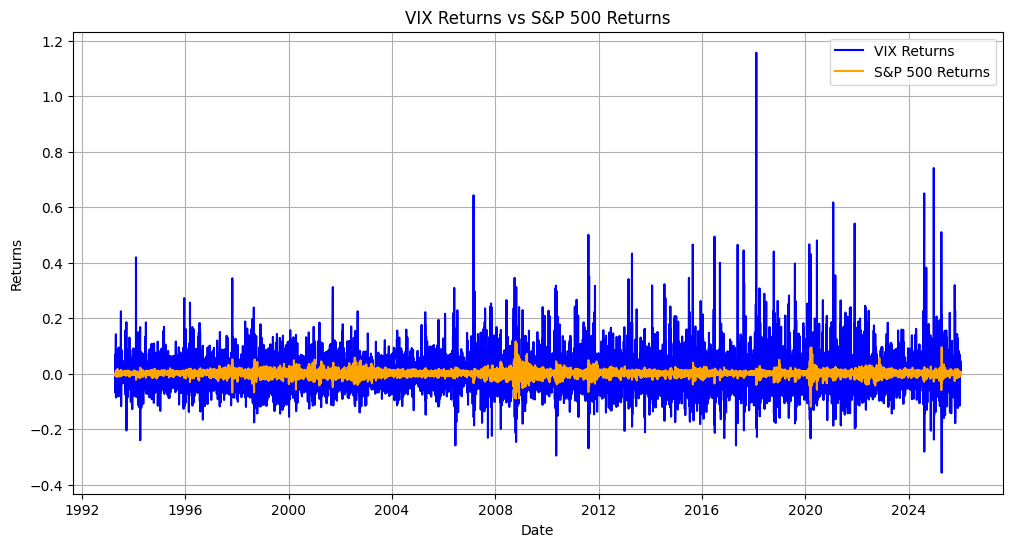

In [5]:
# plot the percent change of VIX and S&P 500
plt.figure(figsize=(12, 6))
plt.plot(vix["date"], vix["vix_returns"], label="VIX Returns", color="blue")
plt.plot(sp500["date"], sp500["sp500_returns"], label="S&P 500 Returns", color="orange")
plt.title("VIX Returns vs S&P 500 Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.grid()
plt.show()

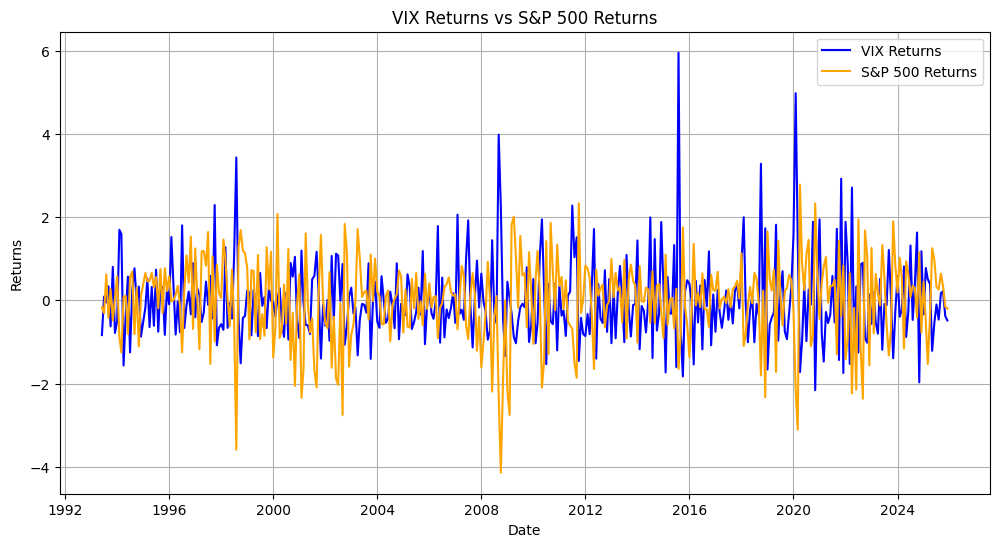

In [6]:
# Get 1 month prices for VIX and S&P 500, then calculate the correlation of the returns and plot the returns
vix_1m = load_yahoo_adjclose("^VIX", start="1993-04-13", end="2026-01-01", interval="1mo").rename(columns={"adjclose": "vix_adjclose"})
sp500_1m = load_yahoo_adjclose("^GSPC", start="1993-04-13", end="2026-01-01", interval="1mo").rename(columns={"adjclose": "sp500_adjclose"})
np.corrcoef(vix["adjclose"], sp500["sp500_adjclose"])[0, 1]

vix_1m["vix_returns"] = vix_1m["vix_adjclose"].pct_change()
sp500_1m["sp500_returns"] = sp500_1m["sp500_adjclose"].pct_change()

# standardize the returns
vix_1m["vix_returns"] = (vix_1m["vix_returns"] - vix_1m["vix_returns"].mean()) / vix_1m["vix_returns"].std()
sp500_1m["sp500_returns"] = (sp500_1m["sp500_returns"] - sp500_1m["sp500_returns"].mean()) / sp500_1m["sp500_returns"].std()

# plot the percent change of VIX and S&P 500
plt.figure(figsize=(12, 6))
plt.plot(vix_1m["date"], vix_1m["vix_returns"], label="VIX Returns", color="blue")
plt.plot(sp500_1m["date"], sp500_1m["sp500_returns"], label="S&P 500 Returns", color="orange")
plt.title("VIX Returns vs S&P 500 Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.grid()
plt.show()

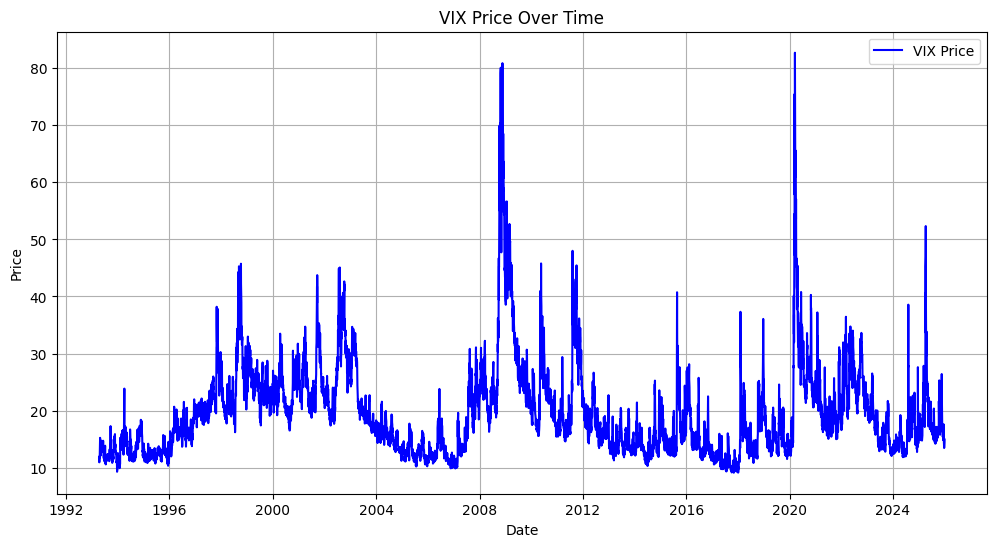

In [7]:
# Plot the VIX price over time
plt.figure(figsize=(12, 6))
plt.plot(vix["date"], vix["adjclose"], label="VIX Price", color="blue")
plt.title("VIX Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [8]:
# calculate the p value of the correlation between VIX and S&P 500 returns
from scipy.stats import pearsonr

corr, p_value = pearsonr(vix["vix_returns"].dropna(), sp500["sp500_returns"].dropna())
print(f"Correlation: {corr}, P-value: {p_value}")

Correlation: -0.7145046245567769, P-value: 0.0


In [10]:
# lag 1 correlation of VIX and S&P 500 returns
lagged_corr, lagged_p_value = pearsonr(vix["vix_returns"].dropna().shift(1).dropna(), sp500["sp500_returns"].dropna())
print(f"Lagged Correlation: {lagged_corr}, Lagged P-value: {lagged_p_value}")

ValueError: `x` and `y` must be broadcastable.